Script do develop evaluation procedure.

In [3]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"]="python"
from gliner import GLiNER
from gliner.training import Trainer, TrainingArguments as GlinerArgs
from gliner.data_processing.collator import DataCollator

from datasets import load_dataset

from dataset_processing import CLIRENER_LABELS_V1, transform_to_ner_format

In [4]:
def ids_to_labels(pred_id_seqs, label_list):
    """
    Convert sequences of prediction IDs into label sequences.

    Args:
        pred_id_seqs (list[list[int]]): e.g. model predictions [[2, 5, 0], ...]
        label_list (list[str]): label names from dataset, e.g. dataset["train"].features["ner_tags"].feature.names

    Returns:
        list[list[str]]: converted label sequences
    """
    return [[label_list[i] for i in seq] for seq in pred_id_seqs]

In [5]:
dataset = load_dataset("P0L3/CliReNER_v_1_1_28_SILVER")
labels = dataset["train"].features["ner_tags"].feature.names

TRUE = dataset["test"]["ner_tags"]

README.md:   0%|          | 0.00/2.36k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/184k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/35.2k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/37.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/803 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/106 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/118 [00:00<?, ? examples/s]

In [6]:
model_path_or_id = "models/GLINER_med_v2_5/checkpoint-final"
model = GLiNER.from_pretrained(model_path_or_id)

config.json not found in /home/p0l3/RAD/CLIRENER/CliReNER/FINETUNES/GLINER/models/GLINER_med_v2_5/checkpoint-final


In [7]:
model_predictions = []
for row in dataset["test"]:
    text = row["text"]
    labels = list(CLIRENER_LABELS_V1)

    entities = model.predict_entities(text, labels, threshold=0.1)
    model_predictions.append({
        "text": text,
        "entities": entities
    })

model_predictions_transformed = transform_to_ner_format(model_predictions, labels)

model_predictions_ids = []
for row in model_predictions_transformed[0]:
    model_predictions_ids.append(row["ner_tags"])

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [9]:
from nervaluate import Evaluator

labels = dataset["train"].features["ner_tags"].feature.names
true = ids_to_labels(TRUE, labels)
  
pred = ids_to_labels(model_predictions_ids, labels)
   
evaluator = Evaluator(true, pred, tags=list(CLIRENER_LABELS_V1), loader="list")

In [10]:
results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()

import pandas as pd

df = pd.DataFrame(results)
print(df)

print("\n##results##:\n")
print("Strict: ", results["strict"])
print("Exact:  ", results["exact"])
print("\##results_by_tag##:\n")
print(results_by_tag)
print("\##result_indices##:\n")
print(result_indices)
print("\##result_indices_by_tag##:\n")
print(result_indices_by_tag)

              ent_type      partial       strict        exact
correct     616.000000   720.000000   574.000000   720.000000
incorrect   183.000000     0.000000   225.000000    79.000000
partial       0.000000    79.000000     0.000000     0.000000
missed        1.000000     1.000000     1.000000     1.000000
spurious    252.000000   252.000000   252.000000   252.000000
possible    800.000000   800.000000   800.000000   800.000000
actual     1051.000000  1051.000000  1051.000000  1051.000000
precision     0.586108     0.722645     0.546147     0.685062
recall        0.770000     0.949375     0.717500     0.900000
f1            0.665586     0.820637     0.620205     0.777958

##results##:

Strict:  {'correct': 574, 'incorrect': 225, 'partial': 0, 'missed': 1, 'spurious': 252, 'possible': 800, 'actual': 1051, 'precision': 0.5461465271170314, 'recall': 0.7175, 'f1': 0.6202052944354403}
Exact:   {'correct': 720, 'incorrect': 79, 'partial': 0, 'missed': 1, 'spurious': 252, 'possible': 800, '

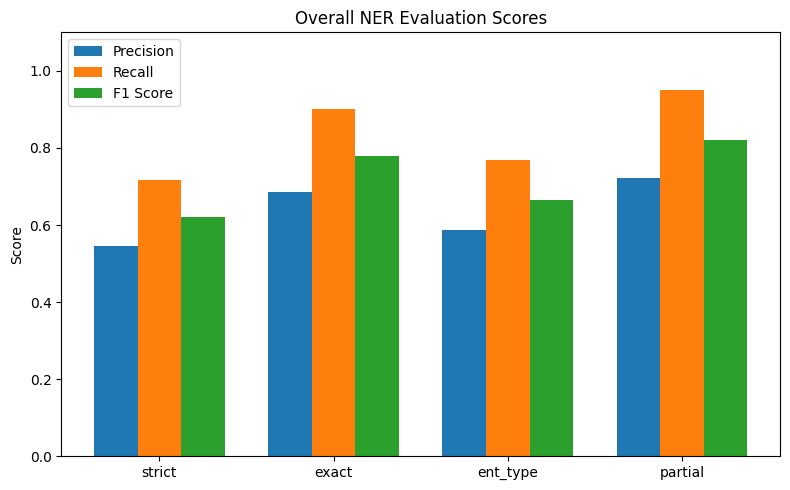

In [11]:
import matplotlib.pyplot as plt

def plot_overall_metrics(results):
    metrics = ['strict', 'exact', 'ent_type', 'partial']
    precision = [results[m]['precision'] for m in metrics]
    recall = [results[m]['recall'] for m in metrics]
    f1 = [results[m]['f1'] for m in metrics]

    x = range(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width for i in x], precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar([i + width for i in x], f1, width, label='F1 Score')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Overall NER Evaluation Scores")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metrics(results)